In [28]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

In [2]:
min_max_data = pd.read_csv("full_min_max_data.csv")
tsne_results = pd.read_csv("tsne_data.csv")

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


---

In [4]:
scaled_no_cat_data = min_max_data.drop(['purpose', 'not.fully.paid', 'credit.policy'], axis=1)
scaled_no_cat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3832 entries, 0 to 3831
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dti                3832 non-null   float64
 1   fico               3832 non-null   float64
 2   days.with.cr.line  3832 non-null   float64
 3   revol.bal          3832 non-null   float64
 4   revol.util         3832 non-null   float64
 5   inq.last.6mths     3832 non-null   float64
 6   delinq.2yrs        3832 non-null   float64
 7   pub.rec            3832 non-null   float64
 8   annual.inc         3832 non-null   float64
dtypes: float64(9)
memory usage: 269.6 KB


In [6]:
complete_clustering = linkage(scaled_no_cat_data, method="complete", metric="euclidean")
average_clustering = linkage(scaled_no_cat_data, method="average", metric="euclidean")
single_clustering = linkage(scaled_no_cat_data, method="single", metric="euclidean")

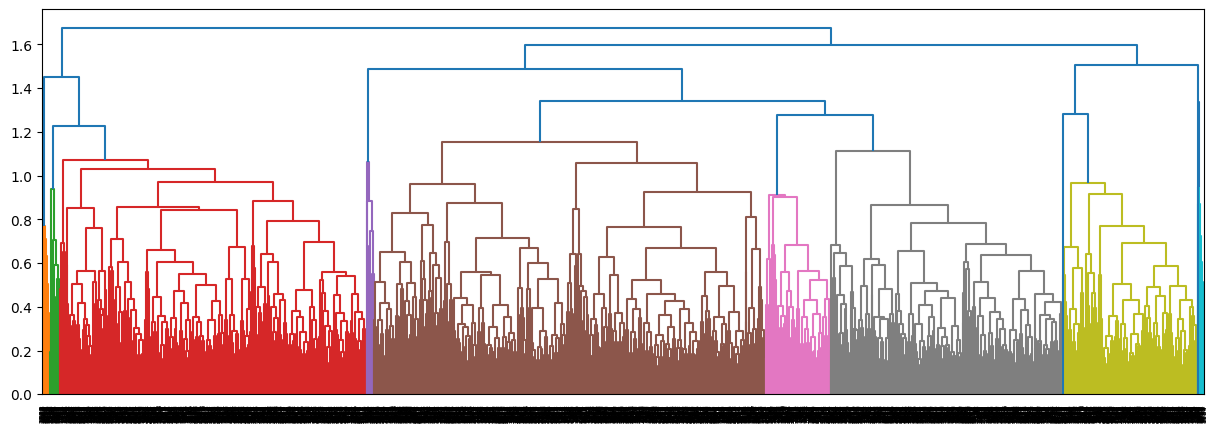

In [14]:
plt.figure(figsize=(15, 5))
dendrogram(complete_clustering)
plt.show()

Optimalus skaičius: $6$ arba $3$

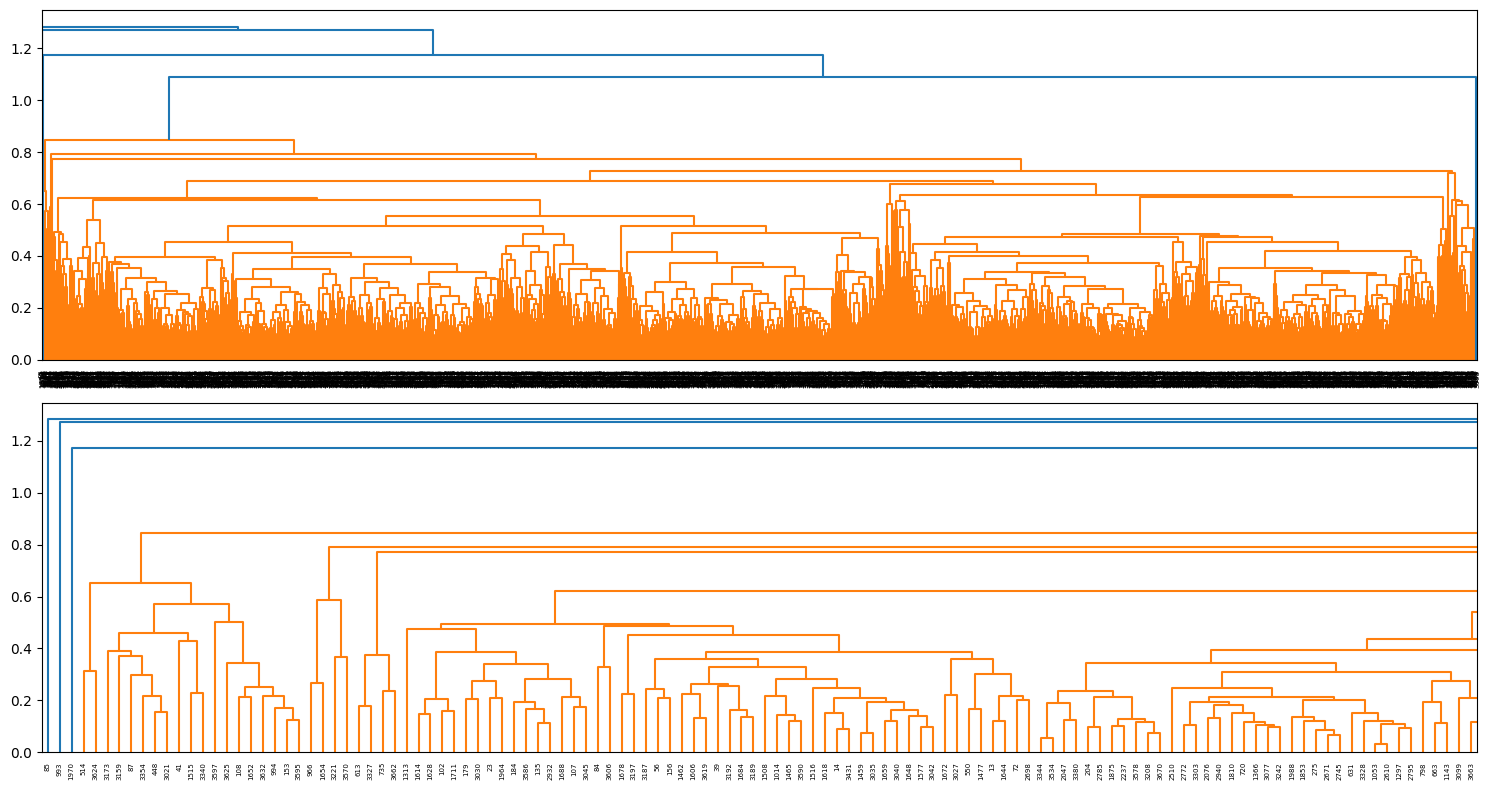

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

dendrogram(average_clustering, ax=ax1)

dendrogram(average_clustering, ax=ax2)
ax2.set_xlim(0, 1200)

plt.tight_layout()
plt.show()

Optimalus skaičius: $3$

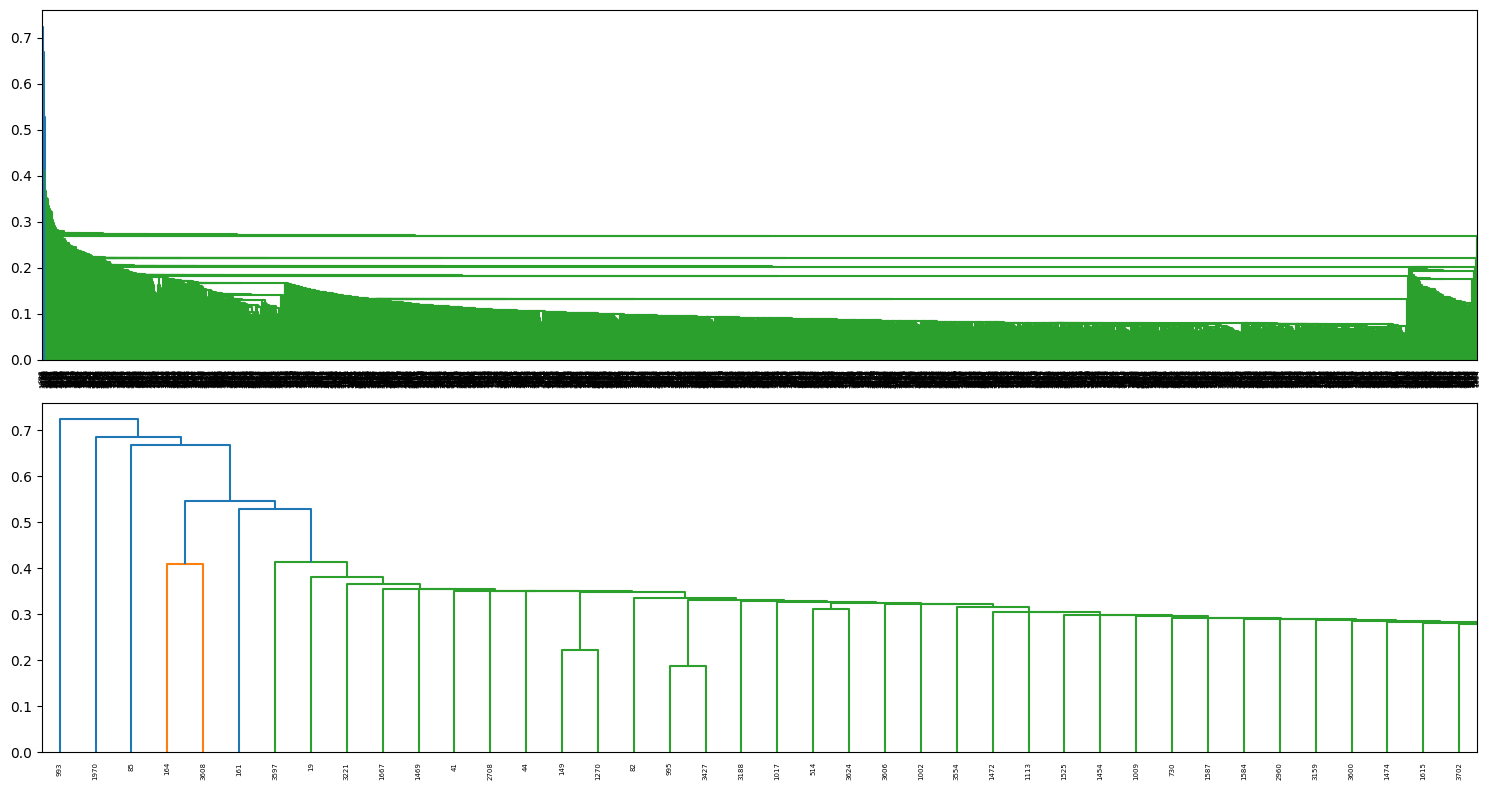

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

dendrogram(single_clustering, ax=ax1)

dendrogram(single_clustering, ax=ax2)
ax2.set_xlim(0, 400)

plt.tight_layout()
plt.show()

Optimalus skaičius: $4$

---

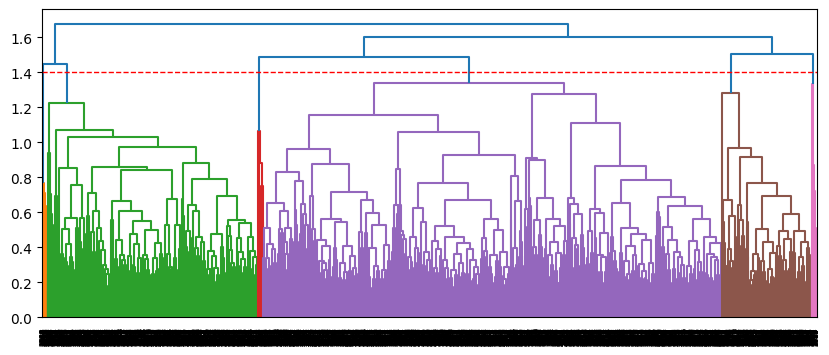

In [27]:
plt.figure(figsize=(10, 4))

dendrogram(complete_clustering, color_threshold=1.4)

plt.axhline(y=1.4, c='red', lw=1, ls='--')
plt.show()

In [34]:
tsne_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3832 entries, 0 to 3831
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tsne_1  3832 non-null   float64
 1   tsne_2  3832 non-null   float64
dtypes: float64(2)
memory usage: 60.0 KB


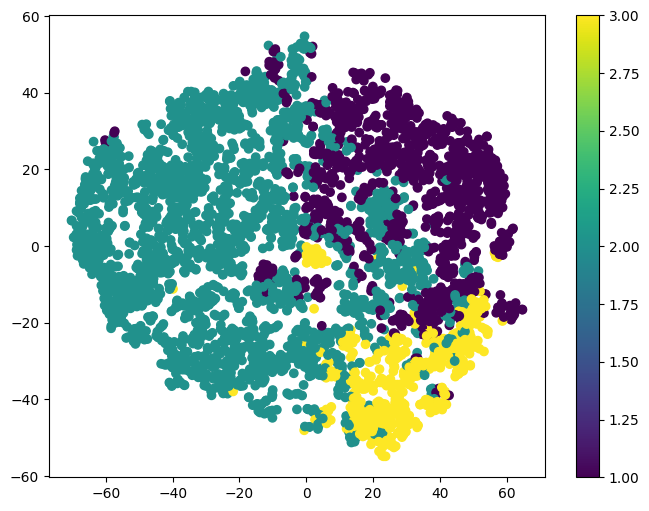

In [44]:
labels = fcluster(complete_clustering, t=3, criterion='maxclust')

plt.figure(figsize=(8, 6))
plt.scatter(tsne_results.loc[:, 'tsne_1'], tsne_results.loc[:, 'tsne_2'], c=labels, cmap='viridis')

plt.colorbar()
plt.show()